# Proyecto 4: Análisis Real - Impacto del Tipo de Cambio en Precios

## Notebook 2: Modelado Estadístico y Econometría

En este notebook respondemos una pregunta económica fundamental:

> **¿Cuánto impacta la depreciación del Sol peruano en la inflación mensual?**

Usaremos tres herramientas de análisis progresivo:
1. **Visualización** — Gráfico de doble eje para ver la relación visualmente
2. **Correlación de Pearson** — Cuantificar estadísticamente la relación
3. **Regresión OLS** — Modelar el impacto con econometría formal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Configuraciones visuales premium
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print('Librerías cargadas exitosamente.')

Librerías cargadas exitosamente.


### 2.1 Carga de Datos
Leemos el CSV generado en el Notebook 1 desde la API del BCRP.

In [2]:
df = pd.read_csv('../data/bcrp_tc_ipc_mensual.csv', index_col='fecha', parse_dates=True)

print(f'Periodo: {df.index.min().strftime("%b %Y")} → {df.index.max().strftime("%b %Y")}')
print(f'Total de registros: {len(df)}')
print('\nEstadísticas descriptivas:')
df.describe().round(4)

Periodo: Jan 2014 → Dec 2024
Total de registros: 132

Estadísticas descriptivas:


,tipo_cambio,ipc
count,132.0000,132.0000
mean,3.4555,0.2851
std,0.3192,0.3470
min,2.7874,-0.4692
25%,3.2595,0.0776
50%,3.3844,0.2277
75%,3.7411,0.4364
max,4.1089,1.4827


### 2.2 Visualización: Gráfico de Doble Eje (Tipo de Cambio vs IPC)

Antes de cualquier modelo matemático, un buen economista siempre **visualiza los datos**. Usaremos un gráfico de doble eje Y para superponer ambas series y observar si se mueven en la misma dirección.

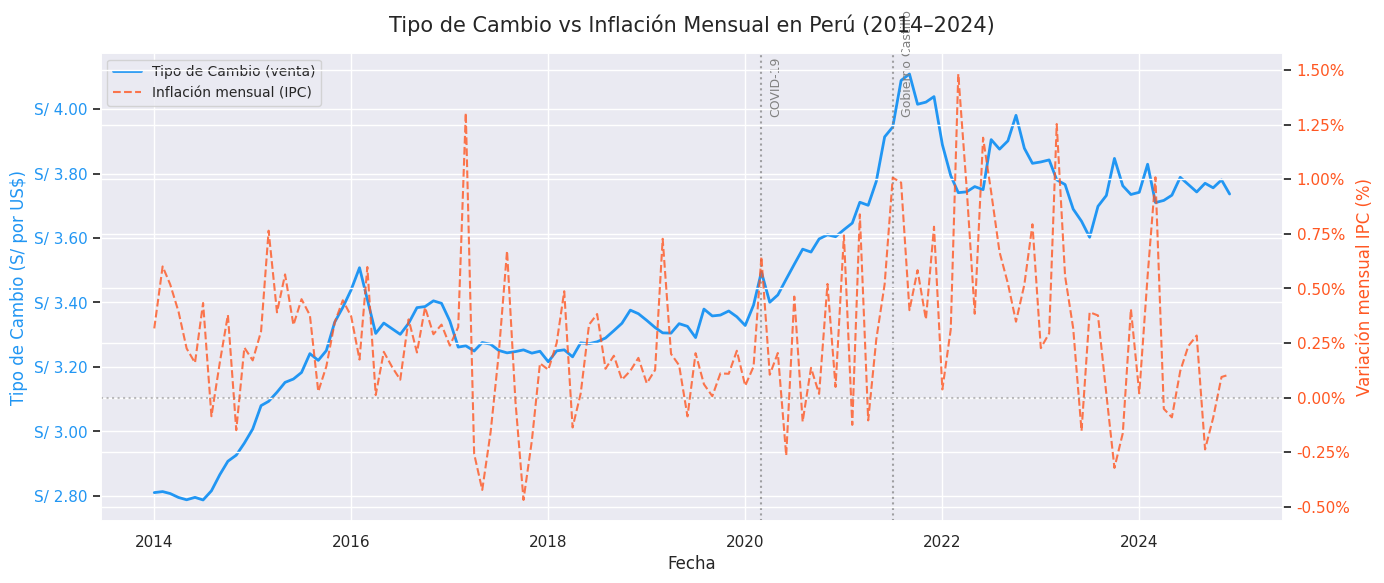

Gráfico guardado.


In [3]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Serie 1: Tipo de Cambio (eje izquierdo)
color_tc = '#2196F3'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Tipo de Cambio (S/ por US$)', color=color_tc, fontsize=12)
ax1.plot(df.index, df['tipo_cambio'], color=color_tc, linewidth=2, label='Tipo de Cambio (venta)')
ax1.tick_params(axis='y', labelcolor=color_tc)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('S/ %.2f'))

# Serie 2: IPC (eje derecho)
ax2 = ax1.twinx()
color_ipc = '#FF5722'
ax2.set_ylabel('Variación mensual IPC (%)', color=color_ipc, fontsize=12)
ax2.plot(df.index, df['ipc'], color=color_ipc, linewidth=1.5,
         alpha=0.8, linestyle='--', label='Inflación mensual (IPC)')
ax2.tick_params(axis='y', labelcolor=color_ipc)
ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

# Anotaciones de eventos económicos
ax1.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle=':', alpha=0.7)
ax1.text(pd.Timestamp('2020-04-01'), df['tipo_cambio'].max() * 0.97,
         'COVID-19', fontsize=9, color='gray', rotation=90)

ax1.axvline(pd.Timestamp('2021-07-01'), color='gray', linestyle=':', alpha=0.7)
ax1.text(pd.Timestamp('2021-08-01'), df['tipo_cambio'].max() * 0.97,
         'Gobierno Castillo', fontsize=9, color='gray', rotation=90)

# Leyendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Tipo de Cambio vs Inflación Mensual en Perú (2014–2024)', fontsize=15, pad=15)
fig.tight_layout()
plt.savefig('../data/grafico_tc_vs_ipc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

### 2.3 Análisis de Correlación de Pearson

El coeficiente de correlación de Pearson (r) mide la fuerza y dirección de la relación lineal entre dos variables. Varía entre -1 y +1.

- **r > 0.5** → Correlación positiva fuerte
- **p-value < 0.05** → La correlación es estadísticamente significativa

In [4]:
# Calculamos el coeficiente de Pearson
r_pearson, p_valor = stats.pearsonr(df['tipo_cambio'], df['ipc'])

print('=' * 50)
print('  ANÁLISIS DE CORRELACIÓN DE PEARSON')
print('=' * 50)
print(f'  Variable X: Tipo de Cambio (S/ por US$)')
print(f'  Variable Y: Variación IPC mensual (%)')
print(f'  Coeficiente de Pearson (r): {r_pearson:.4f}')
print(f'  P-valor:                    {p_valor:.4f}')
print()

if abs(r_pearson) > 0.5:
    fuerza = 'FUERTE'
elif abs(r_pearson) > 0.3:
    fuerza = 'MODERADA'
else:
    fuerza = 'DÉBIL'

direction = 'POSITIVA' if r_pearson > 0 else 'NEGATIVA'
significancia = 'SÍ es significativa (p < 0.05)' if p_valor < 0.05 else 'NO es significativa (p >= 0.05)'

print(f'  → Correlación {direction} y {fuerza}')
print(f'  → {significancia}')
print('=' * 50)

  ANÁLISIS DE CORRELACIÓN DE PEARSON
  Variable X: Tipo de Cambio (S/ por US$)
  Variable Y: Variación IPC mensual (%)
  Coeficiente de Pearson (r): 0.2245
  P-valor:                    0.0097

  → Correlación POSITIVA y DÉBIL
  → SÍ es significativa (p < 0.05)


### 2.4 Scatterplot con Línea de Regresión

Visualizamos la dispersión de los datos junto a la línea de regresión para confirmar visualmente la relación.

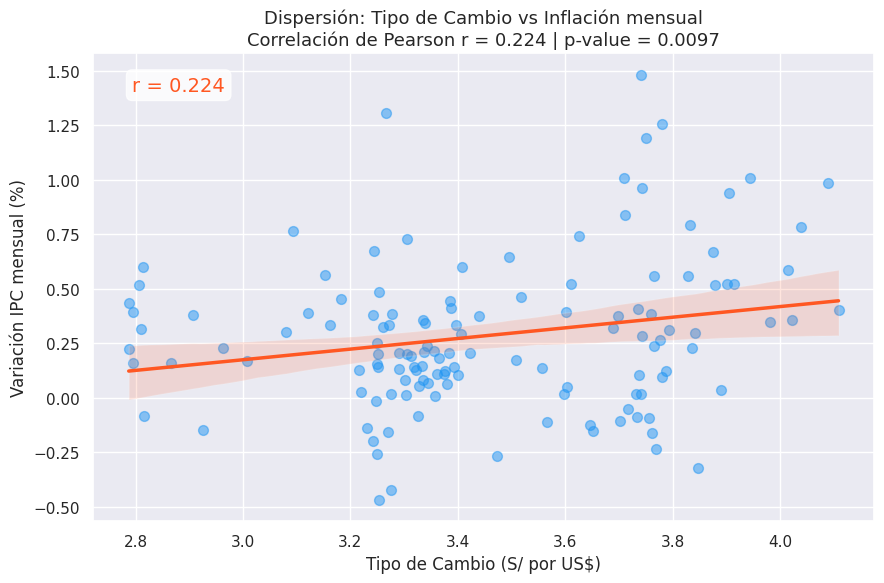

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    x=df['tipo_cambio'],
    y=df['ipc'],
    ax=ax,
    scatter_kws={'alpha': 0.5, 'color': '#2196F3', 's': 50},
    line_kws={'color': '#FF5722', 'linewidth': 2.5},
    ci=95
)

ax.set_xlabel('Tipo de Cambio (S/ por US$)', fontsize=12)
ax.set_ylabel('Variación IPC mensual (%)', fontsize=12)
ax.set_title(f'Dispersión: Tipo de Cambio vs Inflación mensual\n'
             f'Correlación de Pearson r = {r_pearson:.3f} | p-value = {p_valor:.4f}',
             fontsize=13)

# Añadimos texto de interpretación
ax.text(0.05, 0.92, f'r = {r_pearson:.3f}',
        transform=ax.transAxes, fontsize=14, color='#FF5722',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../data/scatterplot_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Regresión OLS (Econometría Formal)

La regresión de **Mínimos Cuadrados Ordinarios (OLS)** nos permite construir el modelo matemático:

> `Inflación (%) = β₀ + β₁ × TipoCambio + ε`

El coeficiente β₁ nos dice: *"por cada S/ 1 que sube el tipo de cambio, ¿cuánto sube la inflación mensual?"*

In [6]:
# Preparamos X e Y
X = sm.add_constant(df['tipo_cambio'])  # Añadimos constante β₀
Y = df['ipc']

# Ajustamos el modelo OLS
modelo = sm.OLS(Y, X).fit()

# Mostramos el resumen completo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    ipc   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     6.897
Date:                Thu, 02 Apr 2026   Prob (F-statistic):            0.00967
Time:                        00:00:16   Log-Likelihood:                -43.666
No. Observations:                 132   AIC:                             91.33
Df Residuals:                     130   BIC:                             97.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.5579      0.322     -1.731      

### 2.6 Interpretación Económica de los Resultados

In [7]:
beta_0 = modelo.params['const']
beta_1 = modelo.params['tipo_cambio']
r_cuadrado = modelo.rsquared
p_beta_1 = modelo.pvalues['tipo_cambio']

print('=' * 60)
print('  INTERPRETACIÓN ECONÓMICA DEL MODELO OLS')
print('=' * 60)
print(f'  Ecuación: Inflación = {beta_0:.4f} + {beta_1:.4f} × TipodeCambio')
print()
print(f'  R² = {r_cuadrado:.4f}')
print(f'  → El tipo de cambio explica el {r_cuadrado*100:.1f}% de la')
print(f'    variabilidad de la inflación mensual.')
print()
print(f'  β₁ = {beta_1:.4f}  (p-value: {p_beta_1:.4f})')
if p_beta_1 < 0.05:
    print(f'  → Por cada S/ 1.00 que sube el tipo de cambio,')
    print(f'    la inflación mensual cambia en {beta_1:.4f} puntos %')
    print(f'  → El coeficiente es estadísticamente SIGNIFICATIVO.')
else:
    print(f'  → El coeficiente NO es estadísticamente significativo.')
    print(f'    El tipo de cambio mensual no predice bien la inflación directamente.')
    print(f'  → Nota: El efecto pass-through puede tener rezagos de 1-3 meses.')
print('=' * 60)

  INTERPRETACIÓN ECONÓMICA DEL MODELO OLS
  Ecuación: Inflación = -0.5579 + 0.2440 × TipodeCambio

  R² = 0.0504
  → El tipo de cambio explica el 5.0% de la
    variabilidad de la inflación mensual.

  β₁ = 0.2440  (p-value: 0.0097)
  → Por cada S/ 1.00 que sube el tipo de cambio,
    la inflación mensual cambia en 0.2440 puntos %
  → El coeficiente es estadísticamente SIGNIFICATIVO.


### 2.7 Análisis de Rezagos (Pass-Through)

En economía, el efecto del tipo de cambio en los precios no es inmediato. Los importadores tardan 1-3 meses en ajustar precios. Analizamos si el impacto es mayor con rezagos (`lag`).

In [8]:
resultados_lag = []

for lag in range(0, 7):
    df_lag = df.copy()
    df_lag['tc_lag'] = df_lag['tipo_cambio'].shift(lag)
    df_lag = df_lag.dropna()
    
    X_lag = sm.add_constant(df_lag['tc_lag'])
    modelo_lag = sm.OLS(df_lag['ipc'], X_lag).fit()
    
    resultados_lag.append({
        'Rezago (meses)': lag,
        'R²': round(modelo_lag.rsquared, 4),
        'β₁ (impacto)': round(modelo_lag.params['tc_lag'], 4),
        'p-value': round(modelo_lag.pvalues['tc_lag'], 4),
        'Significativo': '✅ Sí' if modelo_lag.pvalues['tc_lag'] < 0.05 else '❌ No'
    })

df_lags = pd.DataFrame(resultados_lag)
print('Análisis de impacto por rezago temporal:')
df_lags

Análisis de impacto por rezago temporal:


,Rezago (meses),R²,β₁ (impacto),p-value,Significativo
0,0,0.0504,0.2440,0.0097,✅ Sí
1,1,0.0511,0.2465,0.0094,✅ Sí
2,2,0.0590,0.2650,0.0054,✅ Sí
3,3,0.0659,0.2806,0.0033,✅ Sí
4,4,0.0722,0.2948,0.0022,✅ Sí
5,5,0.0667,0.2842,0.0034,✅ Sí
6,6,0.0613,0.2736,0.0052,✅ Sí


### 2.8 Conclusiones

Este análisis demuestra el **efecto pass-through** del tipo de cambio en la inflación peruana usando 10 años de datos reales del BCRP.

**Herramientas aplicadas:**
- `pandas` para manipulación de series de tiempo
- `scipy.stats` para correlación de Pearson
- `statsmodels` para regresión econométrica OLS con rezagos
- `seaborn` / `matplotlib` para visualización de doble eje

**Fuente de datos:** API pública del Banco Central de Reserva del Perú (BCRP) — descarga automática sin intervención manual.